In [64]:
import warnings
warnings.filterwarnings('ignore')
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath('..'))

from constants import(
    REGION_TO_COUNTIES, 
    FORECAST_CRITICAL,
    FORECAST_HIGH,
    FORECAST_MODERATE,
    FORECAST_LOW,
    FORECAST_NATIONAL,
    IIT_REDUCTION_RATE,
    BRIDGED_TIERS,
    BRIDGED_START_YEAR,
    FORECAST_YEAR_END,
    TIER_COLORS
) 

In [65]:
# Loading updated county_profiles.csv
df = pd.read_csv(
    "../data/processed/county_profiles.csv"
)

print(df.shape)

df.head()

(47, 60)


,county,period,MOH 731_HIV_TB_OnART_15-19_(F)_HV03-24,MOH 731_HIV_TB_OnART_15-19_(M)_HV03-23,MOH 731_HIV_TB_OnART_20-24_(F)_HV03-26,MOH 731_HIV_TB_OnART_20-24_(M)_HV03-25,MOH 731_HIV_TB_OnART_25+_(F)_HV03-28,MOH 731_HIV_TB_OnART_25+_(M)_HV03-27,adults_on_art,art_total_males,...,iit_rate_female_pct,hts_positivity_rate,iit_rate_yoy_change,vls_rate_adult_yoy_change,art_coverage,care_gap_index,iit_rate,vls_rate,cluster,tier
0,Baringo,2025,82,70,164,92,3629,1701,5738,1863,...,0.153,0.006349,0,0,0.5,9.05,0.1530,0.9300,0,High
1,Bomet,2025,234,160,416,175,7745,3616,12346,3951,...,0.153,0.011902,0,0,0.5,9.14,0.1530,0.9305,0,High
2,Bungoma,2025,591,450,1235,400,20203,7717,30596,8567,...,0.091,0.011876,0,0,0.5,5.35,0.0895,0.9618,1,Low
3,Busia,2025,543,467,940,425,23538,11203,37116,12095,...,0.091,0.012605,0,0,0.5,5.21,0.0895,0.9656,1,Low
4,Elgeyo Marakwet,2025,83,68,149,55,3196,1368,4919,1491,...,0.153,0.007338,0,0,0.5,8.29,0.1530,0.9494,0,High


In [66]:
#validate required columns
df.columns.tolist()

['county',
 'period',
 'MOH 731_HIV_TB_OnART_15-19_(F)_HV03-24',
 'MOH 731_HIV_TB_OnART_15-19_(M)_HV03-23',
 'MOH 731_HIV_TB_OnART_20-24_(F)_HV03-26',
 'MOH 731_HIV_TB_OnART_20-24_(M)_HV03-25',
 'MOH 731_HIV_TB_OnART_25+_(F)_HV03-28',
 'MOH 731_HIV_TB_OnART_25+_(M)_HV03-27',
 'adults_on_art',
 'art_total_males',
 'art_total_females',
 'MOH 731_HTS_Tests _(F) (Including PMTCT)_ HV01-02',
 'MOH 731_HTS_Tests _(M)_ HV01-01',
 'hts_tested',
 'hts_tested_males',
 'hts_tested_females',
 'MOH 731_HTS_Positive_2-9 _(M)_ HV01-06',
 'MOH 731_HTS_Positive_2-9 _(F) (Including PMTCT)_ HV01-07',
 'MOH 731_HTS_Positive_10-14 _(F) (Including PMTCT)_HV01-09',
 'MOH 731_HTS_Positive_10-14 _(M)_HV01-08',
 'MOH 731_HTS_Positive_15-19 _(F) (Including PMTCT)_HV01-11',
 'MOH 731_HTS_Positive_15-19 _(M)_HV01-10',
 'MOH 731_HTS_Positive_20-24 _(M)_HV01-12',
 'MOH 731_HTS_Positive_20-24 _(F) (Including PMTCT)_HV01-13',
 'MOH 731_HTS_Positive_25+ _(M)_HV01-14',
 'MOH 731_HTS_Positive_25+ _(F) (Including PMTCT)_H

#### Component B cross-Sectional Comparision

In [67]:
# Rank Counties by IIT Rate
iit_ranking = (
    df[
        ["county", "iit_rate"]
    ]
    .sort_values(
        "iit_rate",
        ascending=False
    )
)

iit_ranking.head()

,county,iit_rate
0,Baringo,0.153
11,Kericho,0.153
43,Uasin Gishu,0.153
42,Turkana,0.153
41,Trans Nzoia,0.153


In [69]:
# Rank counties by VLS Rate
vls_ranking = (
    df[
        ["county", "vls_rate_adult"]
    ]
    .sort_values(
        "vls_rate_adult",
        ascending=True
    )
)

vls_ranking.head()

,county,vls_rate_adult
20,Lamu,0.8136
39,Tana River,0.8893
37,Siaya,0.8947
8,Isiolo,0.9017
38,Taita Taveta,0.9046


In [70]:
# Rank Counties by Care Gap Index
cgi_ranking = (
    df[
        ["county", "care_gap_index"]
    ]
    .sort_values(
        "care_gap_index",
        ascending=False
    )
)

cgi_ranking.head()

,county,care_gap_index
20,Lamu,11.37
36,Samburu,9.78
46,West Pokot,9.69
42,Turkana,9.21
1,Bomet,9.14


In [71]:
# Top 5 Worst and Best Counties
worst_5 = cgi_ranking.head(5)

best_5 = cgi_ranking.tail(5)

print("Top 5 Worst Counties")
display(worst_5)

print("Top 5 Best Counties")
display(best_5)

Top 5 Worst Counties


,county,care_gap_index
20,Lamu,11.37
36,Samburu,9.78
46,West Pokot,9.69
42,Turkana,9.21
1,Bomet,9.14


Top 5 Best Counties


,county,care_gap_index
14,Kirinyaga,5.09
35,Nyeri,5.08
15,Kisii,5.02
45,Wajir,4.51
23,Mandera,4.50


In [72]:
# Create a mapping of county to region
county_to_region = {}

for region, counties in REGION_TO_COUNTIES.items():

    for county in counties:

        county_to_region[county] = region

In [73]:
# Add region column
df["region"] = df["county"].map(
    county_to_region
)

df[
    ["county", "region"]
].head()

,county,region
0,Baringo,Rift Valley
1,Bomet,Rift Valley
2,Bungoma,Western
3,Busia,Western
4,Elgeyo Marakwet,Rift Valley


In [74]:
# Save County Comparision CSV
comparison_df = df[
    [
        "county",
        "region",
        "tier",
        "iit_rate",
        "vls_rate_adult",
        "care_gap_index"
    ]
]

comparison_df.to_csv(
    "../data/processed/county_comparison.csv",
    index=False
)

print(
    "county_comparison.csv saved successfully"
)

county_comparison.csv saved successfully


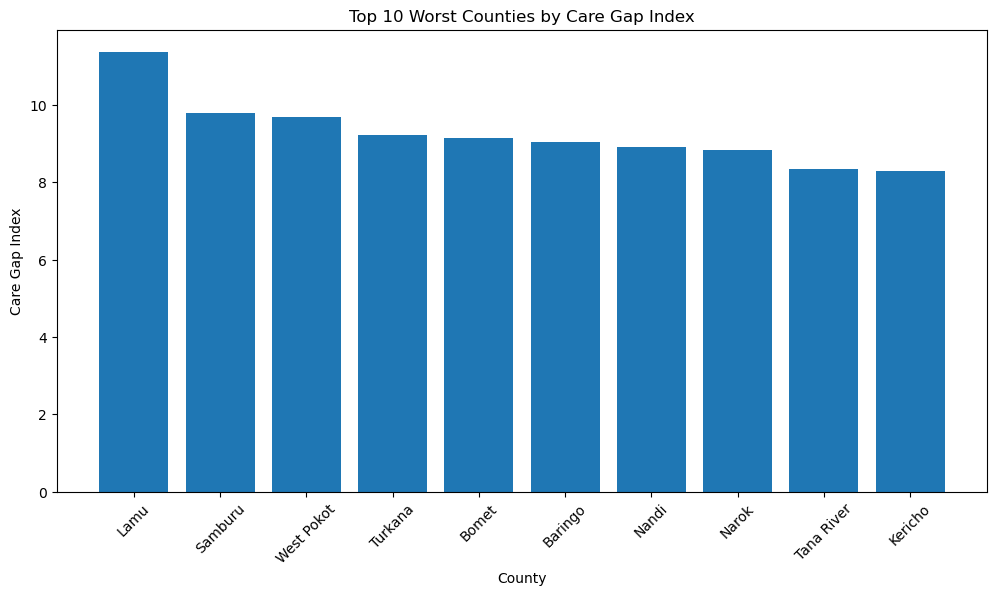

In [75]:
# Top 10 Worst Counties by CGI
top10 = cgi_ranking.head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    top10["county"],
    top10["care_gap_index"]
)

plt.xticks(rotation=45)

plt.title(
    "Top 10 Worst Counties by Care Gap Index"
)

plt.xlabel("County")
plt.ylabel("Care Gap Index")

plt.show()

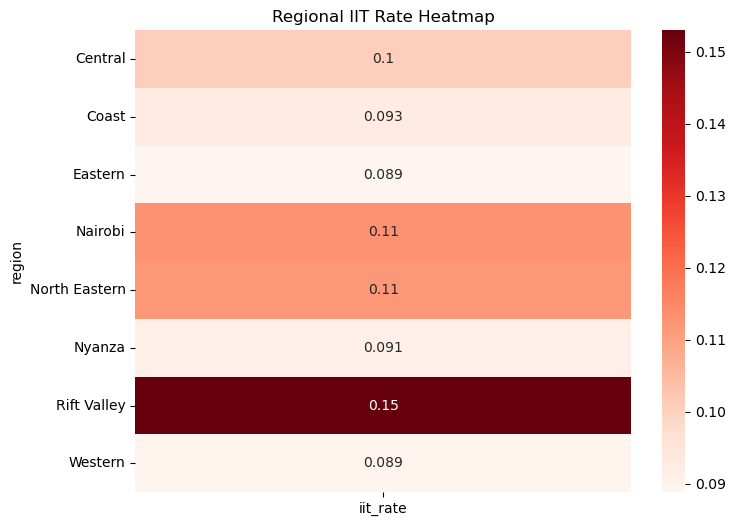

In [76]:
# Regional IIT Heatmap
regional_iit = (
    df.groupby("region")[
        "iit_rate"
    ]
    .mean()
    .reset_index()
)

heatmap_data = regional_iit.pivot_table(
    values="iit_rate",
    index="region"
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap="Reds"
)

plt.title(
    "Regional IIT Rate Heatmap"
)

plt.show()

#### Component A: Scenario A — Flat Projection (BAU)


In [77]:
# Aggregate Tier Rates
tier_rates = (
    df.groupby("tier")[
        [
            "iit_rate",
            "vls_rate_adult",
            "care_gap_index"
        ]
    ]
    .mean()
    .reset_index()
)

tier_rates

,tier,iit_rate,vls_rate_adult,care_gap_index
0,Critical,0.092600,0.813600,11.370000
1,High,0.153000,0.942107,8.631429
2,Low,0.094924,0.961208,5.597600
3,Moderate,0.094107,0.905257,7.761429


In [78]:
# Create Scenario A Projection (BAU — flat rates 2025→2030)
# Assumption: only 2025 data exists, so all future years
# hold the same IIT rate, VLS rate, and CGI as 2025 baseline
scenario_a_rows = []

for _, row in tier_rates.iterrows():

    for year in range(
        2025,
        FORECAST_YEAR_END + 1
    ):

        scenario_a_rows.append({

            "tier": row["tier"],
            "year": year,
            "scenario": "A",

            "iit_rate": row["iit_rate"],

            "vls_rate_adult":
                row["vls_rate_adult"],

            "care_gap_index":
                row["care_gap_index"]
        })

scenario_a_df = pd.DataFrame(
    scenario_a_rows
)

scenario_a_df.head()

,tier,year,scenario,iit_rate,vls_rate_adult,care_gap_index
0,Critical,2025,A,0.0926,0.8136,11.37
1,Critical,2026,A,0.0926,0.8136,11.37
2,Critical,2027,A,0.0926,0.8136,11.37
3,Critical,2028,A,0.0926,0.8136,11.37
4,Critical,2029,A,0.0926,0.8136,11.37


Flat projection Assumption: Since only 2025 data exists all future years remains constant. This is the Business As Usual (BAU) baseline — no intervention.

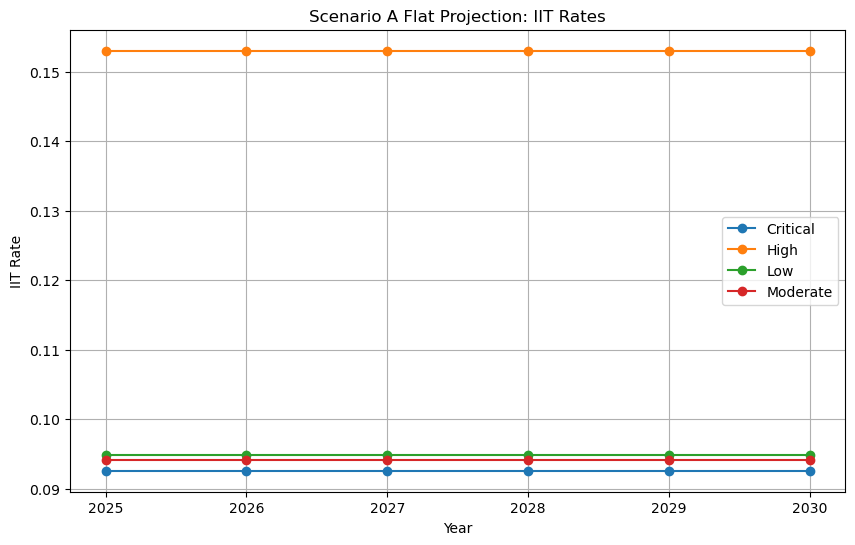

In [79]:
# Plot Scenario A IIT Lines
plt.figure(figsize=(10, 6))

for tier in scenario_a_df["tier"].unique():

    tier_df = scenario_a_df[
        scenario_a_df["tier"] == tier
    ]

    plt.plot(
        tier_df["year"],
        tier_df["iit_rate"],
        marker="o",
        label=tier
    )

plt.title(
    "Scenario A Flat Projection: IIT Rates"
)

plt.xlabel("Year")
plt.ylabel("IIT Rate")

plt.legend()

plt.grid(True)

plt.show()

#### Scenario B — Bridged Gap Intervention

Applies a **30% IIT reduction** (`IIT_REDUCTION_RATE`) to **Critical and High** tier counties (`BRIDGED_TIERS`) starting from 2026 (`BRIDGED_START_YEAR`). Moderate and Low tiers remain unchanged.

VLS improves proportionally using the PEPFAR-documented relationship:
```
delta_iit = iit_rate_new - iit_rate_base   # negative value
vls_rate  = min(1.0, vls_base + (-0.5 × delta_iit))
```
This replaces the flat `vls_rate * 1.10` multiplier which was arbitrary and not evidence-based.



In [80]:
# Create Scenario B Projection (Bridged Gap — 30% IIT reduction)
scenario_b_rows = []

for _, row in tier_rates.iterrows():

    for year in range(
        2025,
        FORECAST_YEAR_END + 1
    ):

        iit_base = row["iit_rate"]
        vls_base = row["vls_rate_adult"]

        if (
            year >= BRIDGED_START_YEAR
            and row["tier"] in BRIDGED_TIERS
        ):

            iit_rate = (
                iit_base *
                (1 - IIT_REDUCTION_RATE)
            )

        else:

            iit_rate = iit_base

        # VLS improves proportionally to IIT reduction
        # Formula: delta_vls = -0.5 x delta_iit
        # (PEPFAR Kenya programme evidence)
        delta_iit = iit_rate - iit_base
        vls_rate = min(
            1.0,
            vls_base + (-0.5 * delta_iit)
        )

        scenario_b_rows.append({

            "tier": row["tier"],
            "year": year,
            "scenario": "B",

            "iit_rate": round(iit_rate, 6),

            "vls_rate_adult": round(vls_rate, 6),

            "care_gap_index":
                row["care_gap_index"]
        })

scenario_b_df = pd.DataFrame(
    scenario_b_rows
)

# Validate VLS never exceeds 1.0
vls_max = scenario_b_df["vls_rate_adult"].max()
print(f"VLS max (must be ≤ 1.0): {vls_max:.6f}")

scenario_b_df.head()

VLS max (must be ≤ 1.0): 0.965057


,tier,year,scenario,iit_rate,vls_rate_adult,care_gap_index
0,Critical,2025,B,0.09260,0.81360,11.37
1,Critical,2026,B,0.06482,0.82749,11.37
2,Critical,2027,B,0.06482,0.82749,11.37
3,Critical,2028,B,0.06482,0.82749,11.37
4,Critical,2029,B,0.06482,0.82749,11.37


In [81]:
# Patients Retained Counter
# Estimates additional patients retained under Scenario B vs Scenario A
# using county-level adults_on_art from county_profiles.csv

patients_rows = []

for _, row in df.iterrows():

    county   = row["county"]
    tier     = row["tier"]
    iit_base = row["iit_rate"]
    art_base = pd.to_numeric(
        row.get("adults_on_art", 0),
        errors="coerce"
    )

    for year in range(2025, FORECAST_YEAR_END + 1):

        years_elapsed = year - 2025

        # Scenario A — IIT unchanged
        retention_a = 1 - iit_base
        art_a = art_base * (retention_a ** years_elapsed)

        # Scenario B — 30% IIT reduction for Critical/High from 2026
        if (
            tier in BRIDGED_TIERS
            and year >= BRIDGED_START_YEAR
        ):
            iit_b = iit_base * (1 - IIT_REDUCTION_RATE)
        else:
            iit_b = iit_base

        retention_b = 1 - iit_b
        art_b = art_base * (retention_b ** years_elapsed)

        patients_rows.append({
            "county":          county,
            "tier":            tier,
            "year":            year,
            "art_retained_a":  round(art_a, 0),
            "art_retained_b":  round(art_b, 0),
            "patients_saved":  round(art_b - art_a, 0),
        })

patients_df = pd.DataFrame(patients_rows)

# Summary by 2030
summary_2030 = (
    patients_df[patients_df["year"] == 2030]
    .groupby("tier")["patients_saved"]
    .sum()
    .reset_index()
)

print("Additional patients retained by 2030 (Scenario B vs A):")
display(summary_2030)
print(f"Total: {int(summary_2030['patients_saved'].sum()):,}")

Additional patients retained by 2030 (Scenario B vs A):


,tier,patients_saved
0,Critical,195.0
1,High,27307.0
2,Low,0.0
3,Moderate,0.0


Total: 27,502


##### Saving Files

Both Scenario A and B are combined into each tier forecast file. This ensures `train_model3.py` and the Streamlit app can read both scenarios from a single file per tier.


In [82]:
# Combine both scenarios
combined_df = pd.concat(
    [scenario_a_df, scenario_b_df],
    ignore_index=True
)

# Save per-tier CSVs (both scenarios A + B in every file)
combined_df[
    combined_df["tier"] == "Critical"
].to_csv(
    FORECAST_CRITICAL,
    index=False
)

combined_df[
    combined_df["tier"] == "High"
].to_csv(
    FORECAST_HIGH,
    index=False
)

combined_df[
    combined_df["tier"] == "Moderate"
].to_csv(
    FORECAST_MODERATE,
    index=False
)

combined_df[
    combined_df["tier"] == "Low"
].to_csv(
    FORECAST_LOW,
    index=False
)

# National projection — both scenarios
national_a = (
    scenario_a_df
    .groupby("year")[["iit_rate", "vls_rate_adult"]]
    .mean()
    .reset_index()
    .assign(scenario="A")
)

national_b = (
    scenario_b_df
    .groupby("year")[["iit_rate", "vls_rate_adult"]]
    .mean()
    .reset_index()
    .assign(scenario="B")
)

national_projection = pd.concat(
    [national_a, national_b],
    ignore_index=True
)

national_projection.to_csv(
    FORECAST_NATIONAL,
    index=False
)

print("Projection CSVs saved successfully")
print(f"  Scenarios in files: {sorted(combined_df['scenario'].unique())}")

Projection CSVs saved successfully
  Scenarios in files: ['A', 'B']


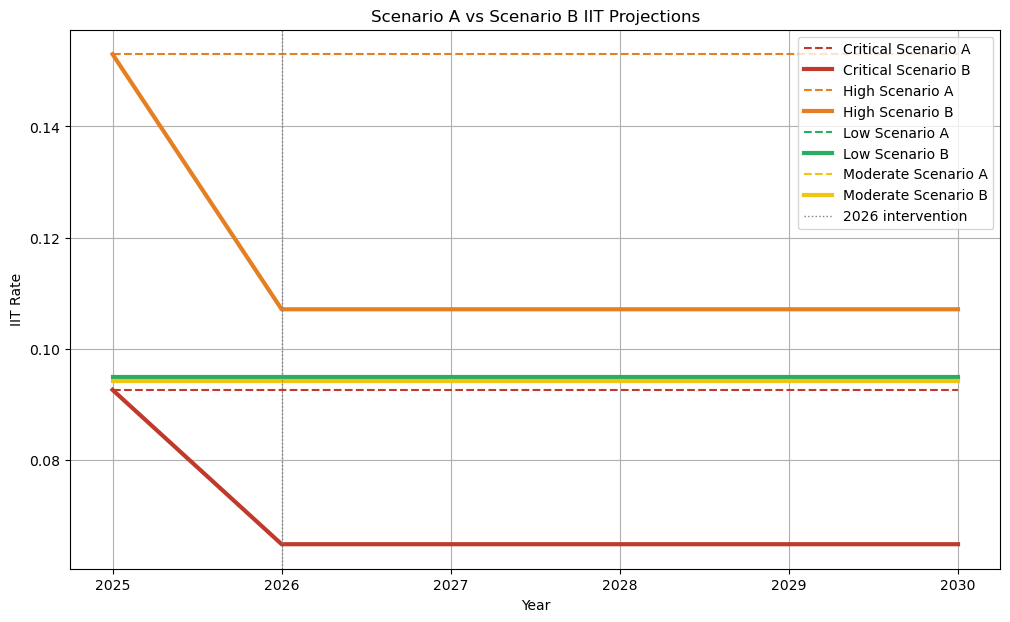

In [83]:
# Dual Scenario IIT Chart
plt.figure(figsize=(12, 7))

for tier in tier_rates["tier"]:

    a_df = scenario_a_df[
        scenario_a_df["tier"] == tier
    ]

    b_df = scenario_b_df[
        scenario_b_df["tier"] == tier
    ]

    color = TIER_COLORS.get(tier, "gray")

    plt.plot(
        a_df["year"],
        a_df["iit_rate"],
        linestyle="--",
        color=color,
        label=f"{tier} Scenario A"
    )

    plt.plot(
        b_df["year"],
        b_df["iit_rate"],
        linewidth=3,
        color=color,
        label=f"{tier} Scenario B"
    )

plt.axvline(
    x=BRIDGED_START_YEAR,
    color="gray",
    linewidth=1,
    linestyle=":",
    label=f"{BRIDGED_START_YEAR} intervention"
)

plt.title(
    "Scenario A vs Scenario B IIT Projections"
)

plt.xlabel("Year")
plt.ylabel("IIT Rate")

plt.legend()
plt.grid(True)
plt.show()

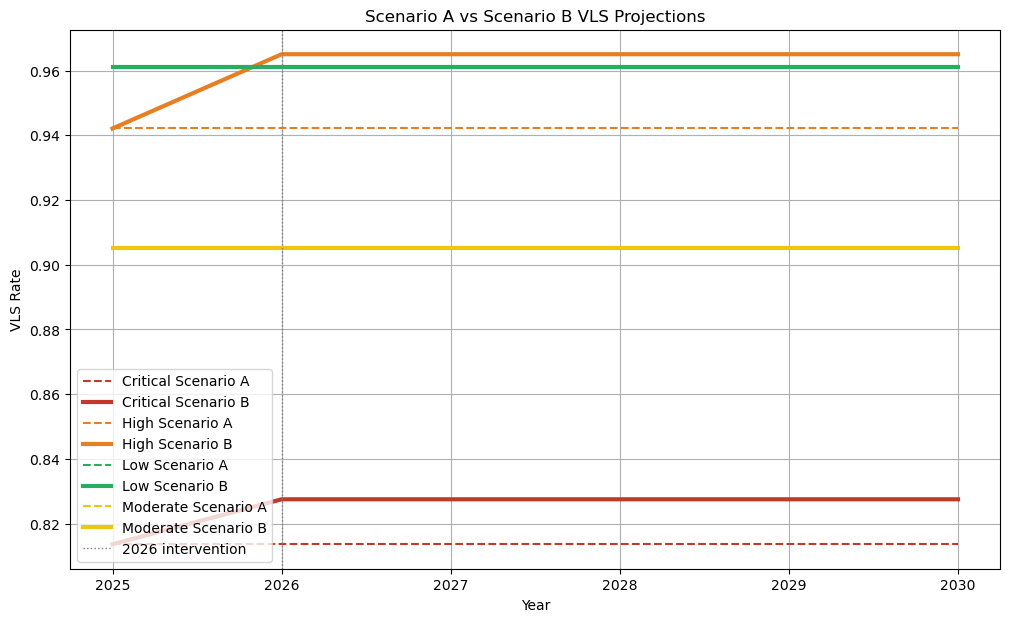

In [84]:
# Dual Scenario VLS Chart
plt.figure(figsize=(12, 7))

for tier in tier_rates["tier"]:

    a_df = scenario_a_df[
        scenario_a_df["tier"] == tier
    ]

    b_df = scenario_b_df[
        scenario_b_df["tier"] == tier
    ]

    color = TIER_COLORS.get(tier, "gray")

    plt.plot(
        a_df["year"],
        a_df["vls_rate_adult"],
        linestyle="--",
        color=color,
        label=f"{tier} Scenario A"
    )

    plt.plot(
        b_df["year"],
        b_df["vls_rate_adult"],
        linewidth=3,
        color=color,
        label=f"{tier} Scenario B"
    )

plt.axvline(
    x=BRIDGED_START_YEAR,
    color="gray",
    linewidth=1,
    linestyle=":",
    label=f"{BRIDGED_START_YEAR} intervention"
)

plt.title(
    "Scenario A vs Scenario B VLS Projections"
)

plt.xlabel("Year")
plt.ylabel("VLS Rate")

plt.legend()
plt.grid(True)
plt.show()

In [85]:
# Final Validation
print("=== Shape Checks ===")
print(f"county_profiles   : {df.shape}")
print(f"scenario_a_df     : {scenario_a_df.shape}")
print(f"scenario_b_df     : {scenario_b_df.shape}")
print(f"combined_df       : {combined_df.shape}")
print(f"national_projection: {national_projection.shape}")
print(f"patients_df       : {patients_df.shape}")

print()
print("=== Scenario Labels ===")
print(f"combined_df scenarios : {sorted(combined_df['scenario'].unique())}")
print(f"national scenarios    : {sorted(national_projection['scenario'].unique())}")

print()
print("=== VLS Sanity Check (must be ≤ 1.0) ===")
print(f"Scenario B VLS max: {scenario_b_df['vls_rate_adult'].max():.6f}")

print()
print("=== Tier Distribution ===")
print(combined_df.groupby(['tier','scenario']).size().unstack())

=== Shape Checks ===
county_profiles   : (47, 61)
scenario_a_df     : (24, 6)
scenario_b_df     : (24, 6)
combined_df       : (48, 6)
national_projection: (12, 4)
patients_df       : (282, 6)

=== Scenario Labels ===
combined_df scenarios : ['A', 'B']
national scenarios    : ['A', 'B']

=== VLS Sanity Check (must be ≤ 1.0) ===
Scenario B VLS max: 0.965057

=== Tier Distribution ===
scenario  A  B
tier          
Critical  6  6
High      6  6
Low       6  6
Moderate  6  6
